In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from imblearn.over_sampling import SMOTE

In [3]:
fp = r"C:\Users\balaj\OneDrive\Desktop\datasets\archive (1)\diabetes_binary_5050split_health_indicators_BRFSS2015.csv".replace("\\","/")
df1 = pd.read_csv(fp)

In [4]:
df1.shape

(70692, 22)

In [5]:
df = df1.iloc[34673:36019]
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
34673,0.0,1.0,1.0,1.0,25.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,10.0,6.0,8.0
34674,0.0,0.0,0.0,1.0,25.0,0.0,0.0,0.0,1.0,0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.0,8.0,6.0,8.0
34675,0.0,0.0,0.0,1.0,28.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,6.0,5.0
34676,0.0,1.0,1.0,1.0,29.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,0.0,1.0,0.0,9.0,6.0,2.0
34677,0.0,1.0,1.0,1.0,27.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,4.0,0.0,30.0,1.0,0.0,10.0,4.0,5.0


In [6]:
df.drop(['Fruits','Veggies', 'Education', 'Income', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'MentHlth', 'GenHlth'], axis=1, inplace=True)

C:\Users\balaj\AppData\Local\Temp\ipykernel_12740\191233218.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(['Fruits','Veggies', 'Education', 'Income', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'MentHlth', 'GenHlth'], axis=1, inplace=True)


In [7]:
df.columns

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'HvyAlcoholConsump',
       'PhysHlth', 'Sex', 'Age'],
      dtype='object')

In [8]:
df['Diabetes_binary'].value_counts()

Diabetes_binary
0.0    673
1.0    673
Name: count, dtype: int64

In [9]:
df.shape

(1346, 13)

In [10]:
x = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

In [11]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
def run_models_with_cv(X, y, folds=5):
    
    # Keeps target-class ratio similar in each fold
    cv = StratifiedKFold(
        n_splits=folds,
        shuffle=True,
        random_state=42
    )
    
    models = {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000))
        ]),
        
        "Decision Tree": DecisionTreeClassifier(
            random_state=42
        ),
        
        "Random Forest": RandomForestClassifier(
            random_state=42
        ),
        
        "Gradient Boosting": GradientBoostingClassifier(
            random_state=42
        ),
        
        "SVM": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC())
        ]),
        
        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ]),
        
        "Naive Bayes": Pipeline([
            ("scaler", StandardScaler()),
            ("model", GaussianNB())
        ])
    }
    
    results = []
    
    for name, model in models.items():
        
        scores = cross_val_score(
            model,
            X,
            y,
            cv=cv,
            scoring="accuracy"
        )
        
        results.append({
            "Model": name,
            "Mean Accuracy (%)": scores.mean() * 100,
            "Std (%)": scores.std() * 100,
            "Fold Scores (%)": np.round(scores * 100, 2)
        })
        
        print("=" * 55)
        print(f"Model: {name}")
        print(f"Fold Accuracies: {np.round(scores * 100, 2)}")
        print(f"Mean Accuracy: {scores.mean() * 100:.2f}%")
        print(f"Standard Deviation: {scores.std() * 100:.2f}%")
    
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(
        by="Mean Accuracy (%)",
        ascending=False
    ).reset_index(drop=True)
    
    return results_df

In [104]:
run_models_with_cv(x,y)

Model: Logistic Regression
Fold Accuracies: [77.41 76.21 75.84 73.61 76.58]
Mean Accuracy: 75.93%
Standard Deviation: 1.27%
Model: Decision Tree
Fold Accuracies: [70.37 65.8  62.83 66.91 66.17]
Mean Accuracy: 66.42%
Standard Deviation: 2.42%
Model: Random Forest
Fold Accuracies: [74.81 73.98 73.23 72.86 71.75]
Mean Accuracy: 73.33%
Standard Deviation: 1.04%
Model: Gradient Boosting
Fold Accuracies: [77.78 74.72 74.35 74.72 71.75]
Mean Accuracy: 74.66%
Standard Deviation: 1.91%
Model: SVM
Fold Accuracies: [77.04 74.72 74.72 74.35 72.86]
Mean Accuracy: 74.74%
Standard Deviation: 1.34%
Model: KNN
Fold Accuracies: [72.22 68.03 72.49 74.35 68.77]
Mean Accuracy: 71.17%
Standard Deviation: 2.39%
Model: Naive Bayes
Fold Accuracies: [76.67 72.86 73.61 76.21 71.38]
Mean Accuracy: 74.14%
Standard Deviation: 2.01%


,Model,Mean Accuracy (%),Std (%),Fold Scores (%)
0,Logistic Regression,75.927578,1.272200,"[77.41, 76.21, 75.84, 73.61, 76.58]"
1,SVM,74.738262,1.338267,"[77.04, 74.72, 74.72, 74.35, 72.86]"
2,Gradient Boosting,74.663362,1.913570,"[77.78, 74.72, 74.35, 74.72, 71.75]"
3,Naive Bayes,74.143742,2.011036,"[76.67, 72.86, 73.61, 76.21, 71.38]"
4,Random Forest,73.327275,1.035098,"[74.81, 73.98, 73.23, 72.86, 71.75]"
5,KNN,71.173069,2.390229,"[72.22, 68.03, 72.49, 74.35, 68.77]"
6,Decision Tree,66.416082,2.417404,"[70.37, 65.8, 62.83, 66.91, 66.17]"


In [114]:
def run_models_train_test_table(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    smote = SMOTE(random_state=42)

    x_train_smote, y_train_smote = smote.fit_resample(
        x_train,
        y_train
    )
    models = {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000))
        ]),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42),
        "SVM": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC())
        ]),
        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ]),
        "Naive Bayes": Pipeline([
            ("scaler", StandardScaler()),
            ("model", GaussianNB())
        ])
    }

    results = []

    for name, model in models.items():
        model.fit( x_train_smote, y_train_smote)

        train_pred = model.predict(x_train_smote)
        test_pred = model.predict(X_test)

        train_acc = accuracy_score(y_train_smote, train_pred) * 100
        test_acc = accuracy_score(y_test, test_pred) * 100

        results.append({
            "Model": name,
            "Train Accuracy (%)": train_acc,
            "Test Accuracy (%)": test_acc,
            "Gap (%)": train_acc - test_acc
        })

    results_df = pd.DataFrame(results).sort_values(
        by="Test Accuracy (%)",
        ascending=False
    ).reset_index(drop=True)

    return results_df

In [115]:
run_models_train_test_table(x, y)

,Model,Train Accuracy (%),Test Accuracy (%),Gap (%)
0,SVM,77.881041,78.518519,-0.637478
1,Logistic Regression,75.000000,78.148148,-3.148148
2,Gradient Boosting,80.947955,77.407407,3.540548
3,Naive Bayes,72.955390,77.037037,-4.081647
4,Random Forest,98.977695,74.074074,24.903621
5,KNN,80.018587,71.111111,8.907476
6,Decision Tree,98.977695,67.407407,31.570288


In [107]:
def run_models_train_test_table(X, y):
    X = pd.DataFrame(data = StandardScaler().fit_transform(X), columns=X.columns)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    x_train_smote, y_train_smote = smote.fit_resample(
        x_train,
        y_train
    )
    models = {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000))
        ]),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42),
        "SVM": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC())
        ]),
        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ]),
        "Naive Bayes": Pipeline([
            ("scaler", StandardScaler()),
            ("model", GaussianNB())
        ])
    }

    results = []

    for name, model in models.items():
        model.fit( x_train_smote, y_train_smote)

        train_pred = model.predict(x_train_smote)
        test_pred = model.predict(X_test)

        train_acc = accuracy_score(y_train_smote, train_pred) * 100
        test_acc = accuracy_score(y_test, test_pred) * 100

        results.append({
            "Model": name,
            "Train Accuracy (%)": train_acc,
            "Test Accuracy (%)": test_acc,
            "Gap (%)": train_acc - test_acc
        })

    results_df = pd.DataFrame(results).sort_values(
        by="Test Accuracy (%)",
        ascending=False
    ).reset_index(drop=True)

    return results_df

In [108]:
run_models_train_test_table(x, y)

,Model,Train Accuracy (%),Test Accuracy (%),Gap (%)
0,Random Forest,98.977695,61.481481,37.496214
1,Decision Tree,98.977695,58.888889,40.088806
2,Gradient Boosting,80.947955,56.296296,24.651659
3,Naive Bayes,72.955390,55.555556,17.399835
4,KNN,80.018587,55.555556,24.463032
5,SVM,77.881041,54.814815,23.066226
6,Logistic Regression,75.000000,50.000000,25.000000


<Axes: >

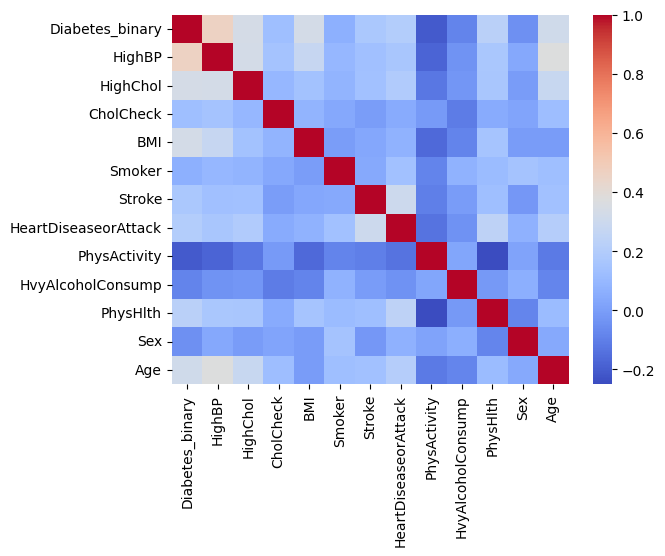

In [109]:
sb.heatmap(df.corr(), cmap="coolwarm")

In [110]:
df.shape

(1346, 13)

In [111]:
df.columns

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'HvyAlcoholConsump',
       'PhysHlth', 'Sex', 'Age'],
      dtype='object')

In [112]:
def run_all_models_metrics(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    models = {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000))
        ]),
        "Decision Tree": DecisionTreeClassifier(random_state=random_state),
        "Random Forest": RandomForestClassifier(random_state=random_state),
        "Gradient Boosting": GradientBoostingClassifier(random_state=random_state),
        "SVM": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(probability=True))
        ]),
        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ]),
        "Naive Bayes": Pipeline([
            ("scaler", StandardScaler()),
            ("model", GaussianNB())
        ])
    }

    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)

        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

        train_acc = accuracy_score(y_train, train_pred) * 100
        test_acc = accuracy_score(y_test, test_pred) * 100
        gap = train_acc - test_acc

        rec = recall_score(y_test, test_pred, zero_division=0)
        f1 = f1_score(y_test, test_pred, zero_division=0)

        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
        else:
            y_prob = model.decision_function(X_test)

        roc_auc = roc_auc_score(y_test, y_prob) * 100

        results.append({
            "Model": name,
            "Accuracy (%)": test_acc,
            "Recall": rec,
            "F1": f1,
            "ROC-AUC (%)": roc_auc,
            "Gap (%)": gap
        })

    results_df = pd.DataFrame(results).sort_values(
        by="Accuracy (%)",
        ascending=False
    ).reset_index(drop=True)

    return results_df

In [113]:
run_all_models_metrics(x,y)

C:\Users\balaj\AppData\Roaming\Python\Python311\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Model,Accuracy (%),Recall,F1,ROC-AUC (%),Gap (%)
0,SVM,78.518519,0.814815,0.791367,82.825789,-0.637478
1,Logistic Regression,78.148148,0.807407,0.787004,84.521262,-3.148148
2,Gradient Boosting,77.407407,0.800000,0.779783,84.145405,3.540548
3,Naive Bayes,77.037037,0.822222,0.781690,83.325103,-4.081647
4,Random Forest,74.074074,0.740741,0.740741,80.233196,24.903621
5,KNN,71.111111,0.718519,0.713235,78.331962,8.907476
6,Decision Tree,67.407407,0.659259,0.669173,67.028807,31.570288


In [95]:
df.columns

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'HvyAlcoholConsump',
       'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth',
       'DiffWalk', 'Sex', 'Age'],
      dtype='object')

In [13]:
df.to_csv('C:/Users/balaj/OneDrive/Desktop/disease prediction models/good dataset/diabetes.csv', index=False)